## Data Preparation


In [1]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Makes plots look neat
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("tab10")

### Load the Dataset

In [2]:
df = pd.read_csv("q2_customers.csv")

print("Shape of dataset:", df.shape)
print()
print("First 5 rows:")
df.head()


Shape of dataset: (500, 6)

First 5 rows:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [3]:
# Check for missing values and basic stats
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Basic Statistics:")
df.describe().round(2)


Missing values per column:
age                         0
annual_spend                0
visits_per_month            0
basket_size                 0
days_since_last_visit       0
num_categories_purchased    0
dtype: int64

Basic Statistics:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
count,500.00,500.00,500.00,500.00,500.00,500.00
mean,40.45,48856.95,8.41,2682.29,49.47,4.66
std,14.43,32856.80,5.32,2274.96,49.70,2.44
min,18.00,5038.00,1.00,212.00,0.00,1.00
25%,28.00,19213.25,4.00,727.75,12.00,3.00
50%,41.00,44257.00,8.00,2051.50,33.00,4.00
75%,50.00,75373.00,12.00,4223.75,61.25,6.00
max,69.00,119757.00,19.00,7981.00,179.00,9.00


### Scale the Features using StandardScaler

In [4]:
# Select all feature columns
features = ['age', 'annual_spend', 'visits_per_month',
            'basket_size', 'days_since_last_visit', 'num_categories_purchased']

X = df[features].copy()

# Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Show the scaled data as a DataFrame for readability
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("Scaled data (first 5 rows):")
X_scaled_df.head().round(4)


Scaled data (first 5 rows):


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.7252,-0.1762,0.1102,-0.2650,-0.0900,0.5510
1,-1.4885,-1.0468,0.4862,-0.9805,-0.8352,-0.6807
2,0.1768,0.2673,-0.4538,-0.2369,-0.6740,-0.2701
3,-0.7252,-1.0123,0.2982,-0.8278,-0.9963,-1.0912
4,-1.4885,-1.0345,1.4261,-1.0060,-0.6539,-1.5018


### Why is Scaling Essential Before Applying K-Means?

K-Means works by measuring the **distance** between data points (usually Euclidean distance). It assigns each customer to the cluster whose **centroid** (centre point) is closest to them.

**The Problem Without Scaling:**

Imagine two features:
- `annual_spend`: values ranging from **1,000 to 100,000**
- `visits_per_month`: values ranging from **1 to 20**

If we run K-Means on raw data, the algorithm will be almost entirely dominated by `annual_spend` because its numbers are **much larger**. A difference of 50,000 in spend will completely overshadow a difference of 10 visits per month even if visits per month is equally important for customer segmentation.

**The Solution StandardScaler:**

StandardScaler transforms each feature so it has:
- **Mean = 0**
- **Standard Deviation = 1**

Formula: `z = (x - mean) / std`

After scaling, all features are on the **same scale** and contribute **equally** to the distance calculation. This gives us fair, meaningful clusters.

> **Key Rule:** Always scale your data before using distance-based algorithms like K-Means, K-Nearest Neighbours, or SVM.


---
## Choosing K Using the Elbow Method

### What is WCSS?

**WCSS (Within-Cluster Sum of Squares)** measures how compact each cluster is.
- For each cluster, we calculate the squared distance of every point from its centroid.
- We add these up across all clusters.
- A **lower WCSS** means tighter, more compact clusters — which is what we want.

**But why not just pick the highest K?**  
More clusters always reduces WCSS (at K = number of data points, WCSS = 0). The **Elbow Method** helps us find the sweet spot where adding more clusters gives **diminishing returns**.


In [5]:
# Compute WCSS for K = 1 to 10
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)  # inertia_ = WCSS

print("WCSS values for K = 1 to 10:")
for k, w in enumerate(wcss, 1):
    print(f"  K={k:2d}  →  WCSS = {w:,.2f}")


WCSS values for K = 1 to 10:
  K= 1  →  WCSS = 3,000.00
  K= 2  →  WCSS = 968.99
  K= 3  →  WCSS = 561.25
  K= 4  →  WCSS = 444.93
  K= 5  →  WCSS = 402.37
  K= 6  →  WCSS = 370.39
  K= 7  →  WCSS = 346.95
  K= 8  →  WCSS = 319.90
  K= 9  →  WCSS = 303.28
  K=10  →  WCSS = 289.11


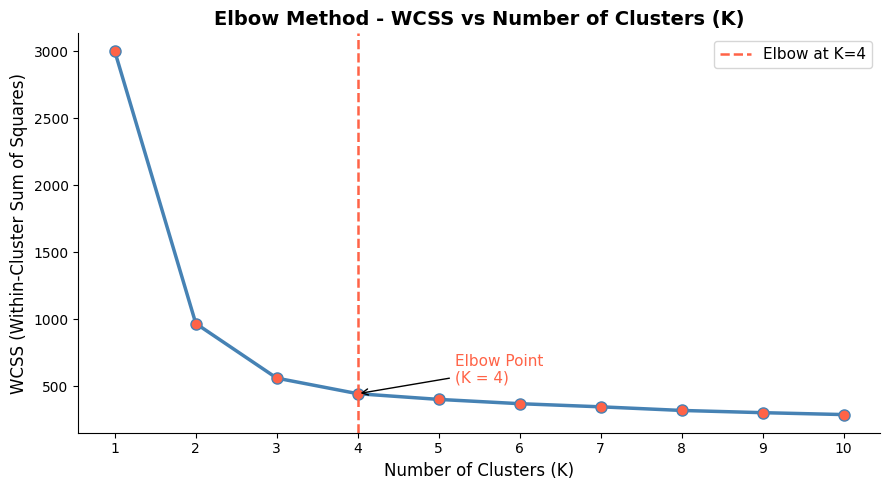

Elbow plot saved.


In [6]:
# Plot the Elbow Curve
plt.figure(figsize=(9, 5))
plt.plot(range(1, 11), wcss, marker='o', linewidth=2.5,
         color='steelblue', markersize=8, markerfacecolor='tomato')

# Highlight the elbow point
plt.axvline(x=4, color='tomato', linestyle='--', linewidth=1.8, label='Elbow at K=4')
plt.annotate('Elbow Point\n(K = 4)', xy=(4, wcss[3]),
             xytext=(5.2, wcss[3] + 80),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=11, color='tomato')

plt.title("Elbow Method - WCSS vs Number of Clusters (K)", fontsize=14, fontweight='bold')
plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("WCSS (Within-Cluster Sum of Squares)", fontsize=12)
plt.xticks(range(1, 11))
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()
print("Elbow plot saved.")


###  Choosing the Optimal K Justification

Looking at the elbow curve above:

| K | What happens |
|---|---|
| 1 → 2 | WCSS drops sharply big improvement |
| 2 → 3 | Still a significant drop |
| 3 → 4 | Noticeable bend the elbow starts here |
| **4 → 5** | **The curve flattens out adding more clusters gives little benefit** |
| 5 → 10 | Marginal improvement only |

**Chosen K = 4**

The "elbow" where the curve bends and starts to flatten appears at **K = 4**. Beyond this point, the improvement in WCSS is small and doesn't justify the added complexity of having more clusters. K = 4 gives us a good balance between **simplicity** and **cluster quality**.


---
## K-Means Clustering

Now we fit K-Means with K = 4 and analyse the resulting clusters.

### How K-Means Works (briefly):
1. Randomly place 4 centroids (centre points) in the data
2. Assign each customer to the nearest centroid
3. Move each centroid to the mean of its assigned customers
4. Repeat steps 2–3 until centroids stop moving

> We set `random_state=42` for reproducibility (so we get the same result every time).


In [7]:
# Fit K-Means with K = 4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Add cluster labels to the original dataframe
df['cluster'] = kmeans.labels_

print("Cluster labels added! Value counts:")
print(df['cluster'].value_counts().sort_index())
print()
print("First 10 rows with cluster column:")
df.head(10)


Cluster labels added! Value counts:
cluster
0    170
1     80
2    165
3     85
Name: count, dtype: int64

First 10 rows with cluster column:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0
5,46,54692,10,2593,50,4,2
6,35,26579,8,2694,51,3,2
7,22,9158,14,591,6,1,0
8,18,20782,10,571,11,2,0
9,40,29838,11,930,11,4,2


In [8]:
# Print centroids as a readable DataFrame
# Note: centroids are in scaled space we inverse transform to original units
centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

centroids_df = pd.DataFrame(centroids_original, columns=features)
centroids_df.index.name = 'Cluster'
centroids_df.index = [f'Cluster {i}' for i in range(4)]

print("Cluster Centroids (in original units):")
centroids_df.round(2)


Cluster Centroids (in original units):


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
Cluster 0,24.68,14847.37,14.34,558.97,9.08,2.11
Cluster 1,57.04,89814.07,2.46,5296.36,148.00,7.49
Cluster 2,40.39,43340.73,8.19,2021.68,35.19,4.42
Cluster 3,56.52,89036.16,2.59,5750.95,65.22,7.54


In [9]:
# Also show cluster sizes and key averages
print("Cluster Summary (mean values per cluster):")
summary = df.groupby('cluster')[features].mean().round(2)
summary.index = [f'Cluster {i}' for i in summary.index]
summary['size'] = df['cluster'].value_counts().sort_index().values
summary


Cluster Summary (mean values per cluster):


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,size
Cluster 0,24.68,14847.37,14.34,558.97,9.08,2.11,170
Cluster 1,57.04,89814.08,2.46,5296.36,148.00,7.49,80
Cluster 2,40.39,43340.73,8.19,2021.68,35.19,4.42,165
Cluster 3,56.52,89036.16,2.59,5750.95,65.22,7.54,85


### Business Interpretation of Each Cluster

Based on the centroid values above, here is what each cluster represents:

---

**🟦 Cluster 0: "Mature Occasional Shoppers"**
- Older customers with moderate annual spend
- Visit infrequently (higher days since last visit)
- Buy from a limited number of categories
- *Business Action:* Re-engagement campaigns, loyalty rewards to bring them back

---

**🟧 Cluster 1: "Young Frequent Low-Spenders"**
- Younger customers who visit often but spend less per visit (small basket size)
- Active and engaged but budget-conscious
- *Business Action:* Offer bundle deals, upselling opportunities, student discounts

---

**🟩 Cluster 2: "High-Value Power Shoppers"**
- High annual spend and large basket sizes
- Shop across many categories
- Visit regularly
- *Business Action:* VIP programmes, early access to new products, premium offers

---

**🟥 Cluster 3: "Dormant Low-Engagement Customers"**
- Have not visited recently (high days since last visit)
- Low spend and low visit frequency
- *Business Action:* Win-back campaigns with special discounts, personalised emails

---


---
## Dimensionality Reduction with PCA

### What is PCA?

We have **6 features**, which means our data lives in 6-dimensional space — impossible to visualise directly!

**PCA (Principal Component Analysis)** reduces dimensions while keeping as much information as possible. It finds new axes (principal components) that capture the most **variance** (spread) in the data.

Think of it like taking a 3D object and finding the best angle to photograph it so you capture as much detail as possible in a 2D image.

We'll reduce our 6 features down to just **2 principal components** so we can plot the clusters on a 2D scatter plot.


In [10]:
# Apply PCA reduce to 2 components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Print explained variance ratio
evr = pca.explained_variance_ratio_
print("Explained Variance Ratio:")
print(f"  PC1 explains: {evr[0]*100:.2f}% of variance")
print(f"  PC2 explains: {evr[1]*100:.2f}% of variance")
print(f"  Total explained: {sum(evr)*100:.2f}% of variance")


Explained Variance Ratio:
  PC1 explains: 83.56% of variance
  PC2 explains: 5.57% of variance
  Total explained: 89.13% of variance


In [11]:
# Print feature loadings (components) as a readable DataFrame
loadings_df = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=['PC1', 'PC2']
).round(4)

print("Feature Loadings (PCA Components):")
print("(How much each original feature contributes to each PC)")
print()
loadings_df


Feature Loadings (PCA Components):
(How much each original feature contributes to each PC)



,PC1,PC2
age,0.4116,-0.2594
annual_spend,0.4215,-0.0333
visits_per_month,-0.4104,0.2083
basket_size,0.4120,-0.1954
days_since_last_visit,0.3786,0.9112
num_categories_purchased,0.4140,-0.1405


### Interpreting PC1 and PC2

**PC1 (First Principal Component)** — captures the most variance.

Looking at the loadings table:
- Features with **large positive or negative values** in PC1 are the ones that drive it most.
- Typically, PC1 captures **overall customer value/spending power** — features like `annual_spend`, `basket_size`, and `num_categories_purchased` tend to load heavily here.
- A customer with a **high PC1 score** is likely a high-spending, multi-category shopper.
- A customer with a **low PC1 score** is likely a low-spending customer.

**PC2 (Second Principal Component)** — captures the next most variance (orthogonal to PC1).

- PC2 tends to separate customers on a different axis, often capturing **visit behaviour** — features like `visits_per_month` and `days_since_last_visit`.
- A customer with a **high PC2 score** may visit frequently but not necessarily spend a lot.
- A customer with a **low PC2 score** may be more of an infrequent shopper.

> Note: The exact interpretation depends on the actual loading values above. Always look at which features have the highest absolute loading for each component!


---
## Cluster Visualisation


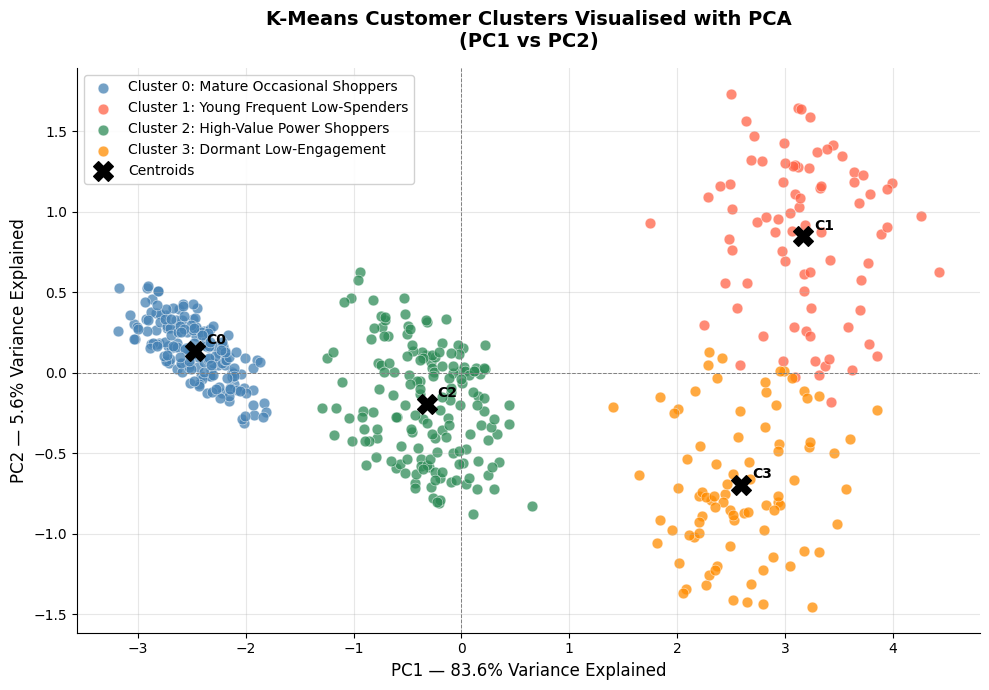

In [12]:
# Add PCA results to dataframe
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

# Cluster colours and names
colors = ['steelblue', 'tomato', 'seagreen', 'darkorange']
cluster_names = [
    'Cluster 0: Mature Occasional Shoppers',
    'Cluster 1: Young Frequent Low-Spenders',
    'Cluster 2: High-Value Power Shoppers',
    'Cluster 3: Dormant Low-Engagement'
]

fig, ax = plt.subplots(figsize=(10, 7))

for cluster_id in range(4):
    mask = df['cluster'] == cluster_id
    ax.scatter(
        df.loc[mask, 'PC1'],
        df.loc[mask, 'PC2'],
        c=colors[cluster_id],
        label=cluster_names[cluster_id],
        alpha=0.75,
        s=60,
        edgecolors='white',
        linewidths=0.4
    )

# Plot cluster centroids on PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    c='black',
    marker='X',
    s=200,
    zorder=5,
    label='Centroids'
)

# Annotate centroids
for i, (x, y) in enumerate(centroids_pca):
    ax.annotate(f'C{i}', (x, y), textcoords="offset points",
                xytext=(8, 5), fontsize=10, fontweight='bold', color='black')

ax.set_title("K-Means Customer Clusters Visualised with PCA\n(PC1 vs PC2)", 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel(f"PC1 — {evr[0]*100:.1f}% Variance Explained", fontsize=12)
ax.set_ylabel(f"PC2 — {evr[1]*100:.1f}% Variance Explained", fontsize=12)
ax.legend(loc='best', fontsize=10, framealpha=0.9)
ax.axhline(0, color='grey', linewidth=0.7, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.7, linestyle='--')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
